In [30]:
# import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

#### 1. Setting up configurations

In [31]:
PROCESSED_DATA_PATH = Path('../../data/processed')
FIGURE_DIR = Path('../../artifacts/figures')

### 2. Load Data Set

In [32]:
df = pd.read_csv(f"{PROCESSED_DATA_PATH}/preprocessed_transformed_data.csv")


### 3. Handle class imbalance

In [33]:
df.head()

,Unnamed: 0,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_Yes,Partner_No,Dependents_No,Dependents_Yes,PhoneService_No,...,PaperlessBilling_Yes,PaperlessBilling_No,PaymentMethod_Electronic check,PaymentMethod_Mailed check,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),Contract,TenureBin,SeniorCitizen,Churn details
0,0,-1.161694,-0.994194,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
1,1,-0.260878,-0.173740,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,0,0
2,2,-0.363923,-0.959649,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1
3,3,-0.747850,-0.195248,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,0,0
4,4,0.196178,-0.940457,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1


In [34]:
df['Churn details'].value_counts()


Churn details
0    5163
1    1869
Name: count, dtype: int64

In [35]:
"""
    In target column Churn details
    Churn (1) : 1869
    Not Churn (0) : 5163

    here going to apply SMOTE 
"""

x = df.drop('Churn details', axis = 1)
y = df['Churn details']

X_train,  X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Size of splitted X_train set : ", X_train.shape)  
print("Size of splitted X_test set : ", X_test .shape)
print("Size of splitted Y_train set : ", Y_train.shape)
print("Size of splitted Y_test set : ", Y_test.shape)


Size of splitted X_train set :  (5625, 44)
Size of splitted X_test set :  (1407, 44)
Size of splitted Y_train set :  (5625,)
Size of splitted Y_test set :  (1407,)


In [36]:
smote = SMOTE (random_state=42)

X_train_resample, Y_train_resample = smote.fit_resample(X_train, Y_train)

print(f"The shape of resampled X_train : {X_train_resample.shape}") 
print(f"The shape of resampled Y_train : {Y_train_resample.shape}")

The shape of resampled X_train : (8260, 44)
The shape of resampled Y_train : (8260,)


In [37]:
Y_train_resample.value_counts()

Churn details
1    4130
0    4130
Name: count, dtype: int64

Text(0, 0.5, 'count')

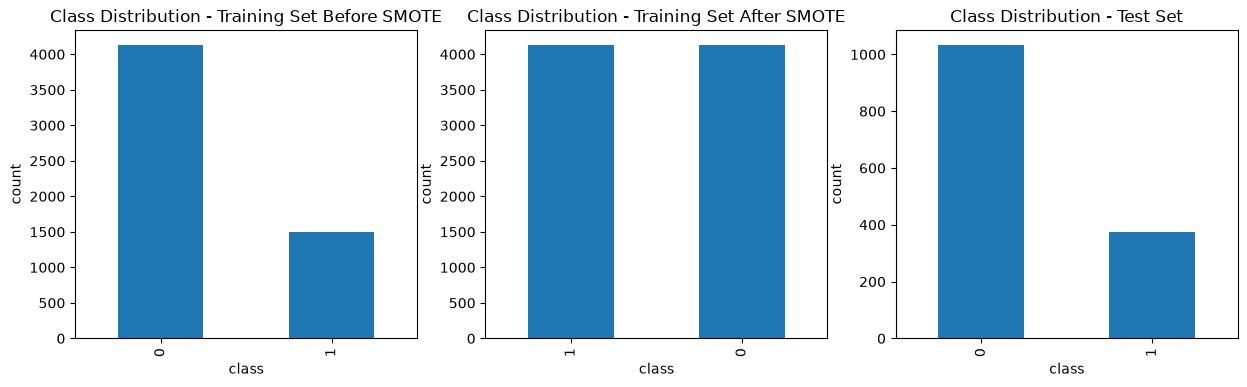

In [38]:
""" Visualize befor and after handle imbalance """

plt.figure(figsize=(15,4))

# before SMOTE
plt.subplot(131)
Y_train.value_counts().plot(kind='bar')
plt.title('Class Distribution - Training Set Before SMOTE')
plt.xlabel('class')
plt.ylabel('count')

plt.subplot(132)
Y_train_resample.value_counts().plot(kind='bar')
plt.title('Class Distribution - Training Set After SMOTE')
plt.xlabel('class')
plt.ylabel('count')

# Test set
plt.subplot(133)
Y_test.value_counts().plot(kind='bar')
plt.title('Class Distribution - Test Set')
plt.xlabel('class')
plt.ylabel('count')

### 4. Save data 

In [ ]:
np.savez(f"{PROCESSED_DATA_PATH}/X_train.npz", X_train_resample)
np.savez(f"{PROCESSED_DATA_PATH}/Y_train.npz", Y_train_resample)
np.savez(f"{PROCESSED_DATA_PATH}/X_test.npz", X_test)
np.savez(f"{PROCESSED_DATA_PATH}/Y_test.npz", Y_test)